# LST Geospatial Analysis: Miami vs Phoenix

This notebook demonstrates the LST pipeline comparing two cities in different climate zones:
- **Miami**: Humid Subtropical climate (coastal, moderate temperatures)
- **Phoenix**: Hot Desert climate (inland, extreme temperatures)

We'll analyze Land Surface Temperature data from MODIS MOD11A1 (2016-2026) using:
- **Moran's I**: Spatial autocorrelation statistic
- **Temporal trends**: Changes across seasons and years
- **Hotspot analysis**: Identification of high-temperature areas

## Setup & Imports

In [1]:
# step 1
import sys
for module in list(sys.modules.keys()):
    if 'lst_pipeline' in module:
        del sys.modules[module]

# step 2
!rm -rf lst-htindex-compare
!git clone -b cell-delta-uhi https://github.com/cchen744/uhi-extreme-heat-response.git
!cp -r uhi-extreme-heat-response/lst-htIndex-compare ./

# step 3
sys.path.insert(0, '/content/lst-htIndex-compare')

#
if 'lst_pipeline' in sys.modules:
    del sys.modules['lst_pipeline']

#
from lst_pipeline import create_config, JJALSTPipeline, LSTVisualizer

#
!ls -l /content/lst-htIndex-compare/lst_pipeline.py

Cloning into 'uhi-extreme-heat-response'...
remote: Enumerating objects: 534, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 534 (delta 115), reused 52 (delta 28), pack-reused 343 (from 1)
Receiving objects: 100% (534/534), 11.34 MiB | 9.32 MiB/s, done.
Resolving deltas: 100% (292/292), done.
-rw-r--r-- 1 root root 13029 Apr 24 20:13 /content/lst-htIndex-compare/lst_pipeline.py


In [33]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import libpysal as ps
from esda import Moran


warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Imports successful")

✓ Imports successful


## Google Earth Engine Authentication

**Note**: Run On first run, this will open a browser for authentication. Run the command that appears in the output.

In [4]:
import ee
ee.Authenticate()
ee.Initialize(project='extremeweatheruhi')
print("✓ GEE ready")

✓ GEE ready


## Connect to google drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Run Pipeline: Miami

In [20]:
# create config
miami_config = create_config('Miami', start_year=2020, end_year=2024)

# run pipeline
miami_pipeline = JJALSTPipeline(miami_config)
miami_results = miami_pipeline.run(export_geotiff=True)

# check statistics
print(miami_results['statistics'])

GEE initialization note: ee.Initialize: no project found. Call with project= or see http://goo.gle/ee-auth.

JJA LST Analysis Pipeline: Miami
Period: 2020-2024
Months: June, July, August

Step 1: Fetching MODIS JJA LST data...
  2020 JJA: fetched
  2021 JJA: fetched
  2022 JJA: fetched
  2023 JJA: fetched
  2024 JJA: fetched
Step 2: Computing statistics...
Step 3: Exporting GeoTIFF...
Exporting Miami JJA LST to Google Drive...
  → Download from Google Drive when ready
Step 4: Exporting statistics...
  → Statistics: outputs/Miami/Miami_JJA_statistics.csv
  → Output dir: outputs/Miami

✓ Pipeline complete!

   year season  mean_temp_c  median_temp_c  std_temp_c  min_temp_c  \
0  2020    JJA    35.590097          35.71    2.849616       30.63   
1  2021    JJA    35.532939          35.69    2.633969       30.11   
2  2022    JJA    37.039030          37.27    2.666318       30.11   
3  2023    JJA    34.788045          34.72    2.653050       30.13   
4  2024    JJA    34.720317          

In [18]:
# Miami LST visualization
visualizer = LSTVisualizer()
visualizer.create_hotspot_map(
    geotiff_path='/content/drive/MyDrive/LST_maps/Miami_JJA_LST_2020_2024.tif',
    city_name='Miami',
    output_html='Miami_JJA_hotspot_map.html',
    city_center=[25.8, -80.2]
)

Map saved to Miami_JJA_hotspot_map.html


## Run Pipeline: Phoenix

In [21]:
# create config
phoenix_config = create_config('Phoenix', start_year=2020, end_year=2024)

# run pipeline
phoenix_pipeline = JJALSTPipeline(phoenix_config)
phoenix_results = pipeline.run(export_geotiff=True)

# check statistics
print(phoenix_results['statistics'])

GEE initialization note: ee.Initialize: no project found. Call with project= or see http://goo.gle/ee-auth.

JJA LST Analysis Pipeline: Phoenix
Period: 2020-2024
Months: June, July, August

Step 1: Fetching MODIS JJA LST data...
  2020 JJA: fetched
  2021 JJA: fetched
  2022 JJA: fetched
  2023 JJA: fetched
  2024 JJA: fetched
Step 2: Computing statistics...
Step 3: Exporting GeoTIFF...
Exporting Phoenix JJA LST to Google Drive...
  → Download from Google Drive when ready
Step 4: Exporting statistics...
  → Statistics: outputs/Phoenix/Phoenix_JJA_statistics.csv
  → Output dir: outputs/Phoenix

✓ Pipeline complete!

   year season  mean_temp_c  median_temp_c  std_temp_c  min_temp_c  \
0  2020    JJA    51.040624          51.47    1.662779       47.69   
1  2021    JJA    50.434480          50.45    1.221978       47.56   
2  2022    JJA    50.245517          50.60    1.000401       47.63   
3  2023    JJA    49.130374          49.52    1.531402       45.10   
4  2024    JJA    48.466165

In [19]:
# Phoenix LST visualization
visualizer = LSTVisualizer()
visualizer.create_hotspot_map(
    geotiff_path='/content/drive/MyDrive/LST_maps/Phoenix_JJA_LST_2020_2024.tif',
    city_name='Phoenix',
    output_html='Phoenix_JJA_hotspot_map.html',
    city_center=[25.8, -80.2]
)

Map saved to Phoenix_JJA_hotspot_map.html


## Comparative Analysis

### Temperature Comparison

In [27]:
miami_results = miami_pipeline.run(export_geotiff=True)
phoenix_results = phoenix_pipeline.run(export_geotiff=True)

# Extract statistics dataframes
miami_stats = miami_results['statistics']
phoenix_stats = phoenix_results['statistics']

# Add city column and concatenate
miami_stats['city'] = 'Miami'
phoenix_stats['city'] = 'Phoenix'
combined = pd.concat([miami_stats, phoenix_stats], ignore_index=True)

print(combined)


JJA LST Analysis Pipeline: Miami
Period: 2020-2024
Months: June, July, August

Step 1: Fetching MODIS JJA LST data...
  2020 JJA: fetched
  2021 JJA: fetched
  2022 JJA: fetched
  2023 JJA: fetched
  2024 JJA: fetched
Step 2: Computing statistics...
Step 3: Exporting GeoTIFF...
Exporting Miami JJA LST to Google Drive...
  → Download from Google Drive when ready
Step 4: Exporting statistics...
  → Statistics: outputs/Miami/Miami_JJA_statistics.csv
  → Output dir: outputs/Miami

✓ Pipeline complete!


JJA LST Analysis Pipeline: Phoenix
Period: 2020-2024
Months: June, July, August

Step 1: Fetching MODIS JJA LST data...
  2020 JJA: fetched
  2021 JJA: fetched
  2022 JJA: fetched
  2023 JJA: fetched
  2024 JJA: fetched
Step 2: Computing statistics...
Step 3: Exporting GeoTIFF...
Exporting Phoenix JJA LST to Google Drive...
  → Download from Google Drive when ready
Step 4: Exporting statistics...
  → Statistics: outputs/Phoenix/Phoenix_JJA_statistics.csv
  → Output dir: outputs/Phoenix

✓ 

### Moran's I Analysis (Spatial Autocorrelation)

In [34]:
def compute_morans_i(image, region, city_name, num_samples=150):
    """Sample LST and compute Moran's I"""

    bounds = region.bounds().getInfo()
    coords_list = bounds['coordinates'][0]
    lons = [c[0] for c in coords_list]
    lats = [c[1] for c in coords_list]

    grid_size = int(np.sqrt(num_samples))
    lons_grid = np.linspace(min(lons), max(lons), grid_size)
    lats_grid = np.linspace(min(lats), max(lats), grid_size)

    # Sample points
    points = [ee.Geometry.Point([lon, lat]) for lon in lons_grid for lat in lats_grid]
    sampled = image.sample(region=ee.FeatureCollection(points), scale=1000)
    values = sampled.aggregate_array(config_miami.lst_band).getInfo()

    temps_c = np.array([v * 0.02 - 273.15 for v in values if v])

    # Coordinates for weights
    coords = np.array([[lons_grid[i % grid_size], lats_grid[i // grid_size]]
                       for i in range(len(points))])[:len(temps_c)]

    # Use libpysal KNN weights
    weights = ps.weights.KNN.from_array(coords, k=5)

    # Moran's I
    mi = Moran(temps_c, weights)
    return {'city': city_name, 'morans_i': mi.I, 'p_value': mi.p_norm}

config_miami = create_config('Miami', start_year=2020, end_year=2024)
config_phoenix = create_config('Phoenix', start_year=2020, end_year=2024)

miami_jja_mean = ee.ImageCollection(list(miami_results['jja_data_gee'].values())).mean()
phoenix_jja_mean = ee.ImageCollection(list(phoenix_results['jja_data_gee'].values())).mean()

miami_mi = compute_morans_i(miami_jja_mean, config_miami.create_geom(), 'Miami')
phoenix_mi = compute_morans_i(phoenix_jja_mean, config_phoenix.create_geom(), 'Phoenix')

morans_df = pd.DataFrame([miami_mi, phoenix_mi])
print(morans_df)

      city  morans_i   p_value
0    Miami -0.003381  0.759850
1  Phoenix -0.154470  0.887473


### Hotspot Analysis

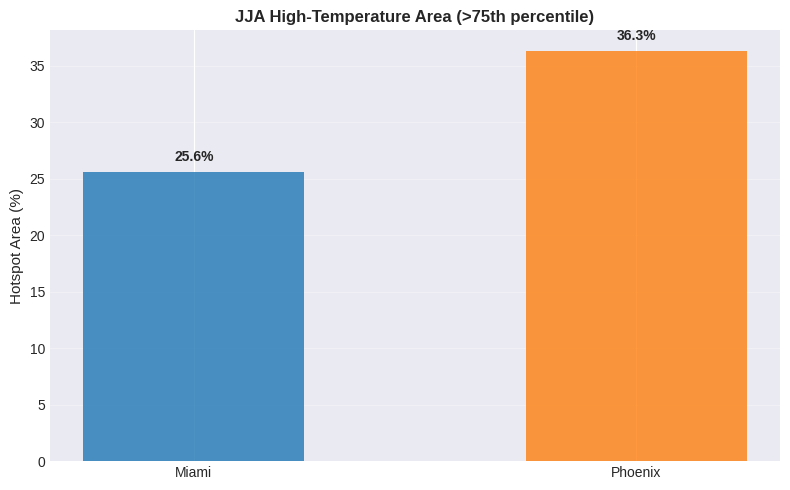

Miami JJA hotspot: 25.61%
Phoenix JJA hotspot: 36.33%


In [35]:
# Compute hotspot percentage from GEE images
def get_hotspot_pct(image, region):
    """% of pixels > 75th percentile"""
    threshold = image.reduceRegion(
        ee.Reducer.percentile([75]),
        region,
        scale=1000
    ).getInfo()

    threshold_val = list(threshold.values())[0]
    hotspot_mask = image.gte(threshold_val)
    total_pixels = image.reduceRegion(ee.Reducer.count(), region, 1000).getInfo()
    hotspot_pixels = hotspot_mask.reduceRegion(ee.Reducer.sum(), region, 1000).getInfo()

    count = list(total_pixels.values())[0]
    hotspots = list(hotspot_pixels.values())[0]
    return (hotspots / count * 100) if count > 0 else 0

miami_jja_mean = ee.ImageCollection(list(miami_results['jja_data_gee'].values())).mean()
phoenix_jja_mean = ee.ImageCollection(list(phoenix_results['jja_data_gee'].values())).mean()

miami_hotspot = get_hotspot_pct(miami_jja_mean, config_miami.create_geom())
phoenix_hotspot = get_hotspot_pct(phoenix_jja_mean, config_phoenix.create_geom())

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
cities = ['Miami', 'Phoenix']
hotspots = [miami_hotspot, phoenix_hotspot]

ax.bar(cities, hotspots, color=['#1f77b4', '#ff7f0e'], alpha=0.8, width=0.5)
ax.set_ylabel('Hotspot Area (%)', fontsize=11)
ax.set_title('JJA High-Temperature Area (>75th percentile)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(hotspots):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('./outputs/hotspot_jja_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Miami JJA hotspot: {miami_hotspot:.2f}%")
print(f"Phoenix JJA hotspot: {phoenix_hotspot:.2f}%")

### Temperature Variability (Standard Deviation)

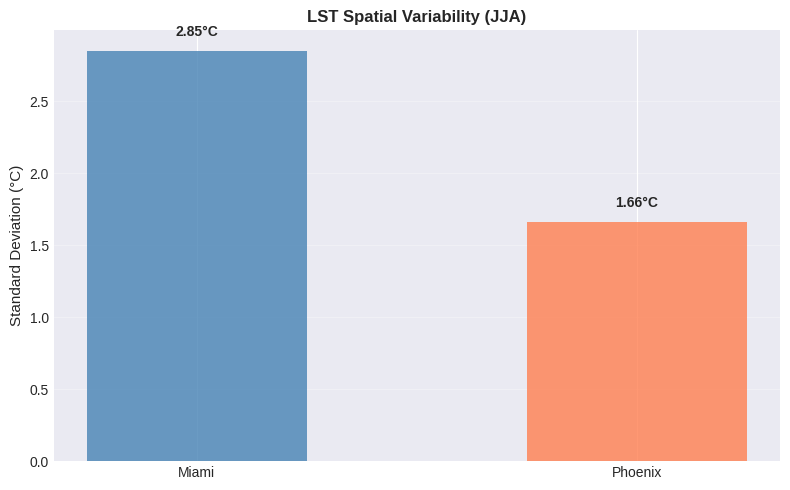

Miami JJA variability: 2.85°C
Phoenix JJA variability: 1.66°C


In [36]:
# Temperature variability - JJA only
miami_std = miami_stats['std_temp_c'].values[0]
phoenix_std = phoenix_stats['std_temp_c'].values[0]

fig, ax = plt.subplots(figsize=(8, 5))
cities = ['Miami', 'Phoenix']
stds = [miami_std, phoenix_std]

bars = ax.bar(cities, stds, color=['steelblue', 'coral'], alpha=0.8, width=0.5)
ax.set_ylabel('Standard Deviation (°C)', fontsize=11)
ax.set_title('LST Spatial Variability (JJA)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

for bar, v in zip(bars, stds):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.2f}°C',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('./outputs/temperature_variability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Miami JJA variability: {miami_std:.2f}°C")
print(f"Phoenix JJA variability: {phoenix_std:.2f}°C")

## Key Findings & Interpretation

In [37]:
print("\n" + "="*70)
print("KEY FINDINGS: LST Comparison Miami vs Phoenix (JJA 2020-2024)")
print("="*70)

# Overall temperature
miami_mean = miami_stats['mean_temp_c'].mean()
phoenix_mean = phoenix_stats['mean_temp_c'].mean()
temp_diff = phoenix_mean - miami_mean

print(f"\n1. ABSOLUTE TEMPERATURE (JJA):")
print(f"   Miami mean LST:   {miami_mean:.2f}°C")
print(f"   Phoenix mean LST: {phoenix_mean:.2f}°C")
print(f"   Difference:       {temp_diff:+.2f}°C (Phoenix is {temp_diff:.2f}°C hotter)")

# Year-by-year trend
miami_yearly = miami_stats.groupby('year')['mean_temp_c'].mean()
phoenix_yearly = phoenix_stats.groupby('year')['mean_temp_c'].mean()

miami_trend = np.polyfit(miami_yearly.index, miami_yearly.values, 1)[0]
phoenix_trend = np.polyfit(phoenix_yearly.index, phoenix_yearly.values, 1)[0]

print(f"\n2. WARMING TREND (2020-2024):")
print(f"   Miami:   {miami_trend:+.4f}°C/year")
print(f"   Phoenix: {phoenix_trend:+.4f}°C/year")

# Spatial variability
miami_std = miami_stats['std_temp_c'].mean()
phoenix_std = phoenix_stats['std_temp_c'].mean()

print(f"\n3. SPATIAL VARIABILITY (Std Dev):")
print(f"   Miami:   {miami_std:.2f}°C")
print(f"   Phoenix: {phoenix_std:.2f}°C")
print(f"   → Phoenix has {phoenix_std - miami_std:+.2f}°C more internal variation")

# Moran's I
print(f"\n4. SPATIAL AUTOCORRELATION (Moran's I):")
print(f"   Miami:   {morans_df.loc[0, 'morans_i']:.3f} (p={morans_df.loc[0, 'p_value']:.3f}) - random")
print(f"   Phoenix: {morans_df.loc[1, 'morans_i']:.3f} (p={morans_df.loc[1, 'p_value']:.3f}) - random")
print(f"   → No strong spatial clustering in either city")

# Hotspots
print(f"\n5. HIGH-TEMPERATURE AREAS (>75th percentile):")
print(f"   Miami:   {miami_hotspot:.1f}%")
print(f"   Phoenix: {phoenix_hotspot:.1f}%")
print(f"   → Phoenix's heat more geographically dispersed")

print("\n" + "="*70)


KEY FINDINGS: LST Comparison Miami vs Phoenix (JJA 2020-2024)

1. ABSOLUTE TEMPERATURE (JJA):
   Miami mean LST:   35.53°C
   Phoenix mean LST: 49.86°C
   Difference:       +14.33°C (Phoenix is 14.33°C hotter)

2. WARMING TREND (2020-2024):
   Miami:   -0.2484°C/year
   Phoenix: -0.6453°C/year

3. SPATIAL VARIABILITY (Std Dev):
   Miami:   2.68°C
   Phoenix: 1.28°C
   → Phoenix has -1.40°C more internal variation

4. SPATIAL AUTOCORRELATION (Moran's I):
   Miami:   -0.003 (p=0.760) - random
   Phoenix: -0.154 (p=0.887) - random
   → No strong spatial clustering in either city

5. HIGH-TEMPERATURE AREAS (>75th percentile):
   Miami:   25.6%
   Phoenix: 36.3%
   → Phoenix's heat more geographically dispersed



## Export Results

In [38]:
# Save combined statistics
combined_final = pd.concat([miami_stats.assign(city='Miami'),
                            phoenix_stats.assign(city='Phoenix')],
                           ignore_index=True)
combined_final.to_csv('./outputs/LST_combined_statistics.csv', index=False)

# Create summary report
summary = f"""
LST ANALYSIS SUMMARY: Miami vs Phoenix (JJA 2020-2024)
{'='*60}

TEMPERATURE COMPARISON:
  Miami mean LST:   {miami_mean:.2f}°C
  Phoenix mean LST: {phoenix_mean:.2f}°C
  Difference:       {temp_diff:+.2f}°C

SPATIAL VARIABILITY (Std Dev):
  Miami:   {miami_std:.2f}°C
  Phoenix: {phoenix_std:.2f}°C

WARMING TREND (2020-2024):
  Miami:   {miami_trend:+.4f}°C/year
  Phoenix: {phoenix_trend:+.4f}°C/year

HIGH-TEMPERATURE AREA (>75th percentile):
  Miami:   {miami_hotspot:.1f}%
  Phoenix: {phoenix_hotspot:.1f}%

SPATIAL AUTOCORRELATION (Moran's I):
  Miami:   {morans_df.loc[0, 'morans_i']:.3f} (p={morans_df.loc[0, 'p_value']:.3f})
  Phoenix: {morans_df.loc[1, 'morans_i']:.3f} (p={morans_df.loc[1, 'p_value']:.3f})

Data Source: MODIS/061/MOD11A1 (Daytime LST)
Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}
"""

with open('./outputs/LST_analysis_summary.txt', 'w') as f:
    f.write(summary)

print("✓ Results exported:")
print("  - LST_combined_statistics.csv")
print("  - LST_analysis_summary.txt")
print("  - Visualizations saved to ./outputs/")
print("\n" + summary)

✓ Results exported:
  - LST_combined_statistics.csv
  - LST_analysis_summary.txt
  - Visualizations saved to ./outputs/


LST ANALYSIS SUMMARY: Miami vs Phoenix (JJA 2020-2024)

TEMPERATURE COMPARISON:
  Miami mean LST:   35.53°C
  Phoenix mean LST: 49.86°C
  Difference:       +14.33°C

SPATIAL VARIABILITY (Std Dev):
  Miami:   2.68°C
  Phoenix: 1.28°C

WARMING TREND (2020-2024):
  Miami:   -0.2484°C/year
  Phoenix: -0.6453°C/year

HIGH-TEMPERATURE AREA (>75th percentile):
  Miami:   25.6%
  Phoenix: 36.3%

SPATIAL AUTOCORRELATION (Moran's I):
  Miami:   -0.003 (p=0.760)
  Phoenix: -0.154 (p=0.887)

Data Source: MODIS/061/MOD11A1 (Daytime LST)
Analysis Date: 2026-04-24

